# Valuation and Hedging of Options
In this project, we price and hedge European and American options using different methods.
We select Apple Inc. (AAPL) as the underlying asset and impleemnt the Black-Scholes model, Monte-Carlo simulations under Geometric Brownian Motion, and the Binomial model for American options.

All formulas are implemented manually in Python as required.

In [83]:
import numpy as np
import yfinance as yf
import pandas as pd
import math
from scipy.stats import norm
import matplotlib.pyplot as plt
import datetime

## Config

* Period: 01-01-2024 -- 01-01-2025 (1 year).
* For the risk free rate we decide to use 1Y US treasury yield at that time (approx. 4%). **Source: https://fred.stlouisfed.org/series/DGS1**
* Assume strike (K) as the mean price of the asset.

* As from the recent update of yfinance, there would no longer be "Adj Close", and by default the adjusted close price would be "Close".

In [200]:
ticker="AAPL"
df = yf.download("AAPL", start="2025-03-01", end="2026-03-01")

S=df["Close"].dropna()
r=0.04 #risk free rate (1Y )
T=1 #time to maturity (1Y)
log_returns=np.log(S/S.shift(1)).dropna()
sigma=log_returns.std()*np.sqrt(252) #annualized volatility
K=S.mean()
S0=S.iloc[-1] #current stock price

S0=float(S0.iloc[0])
K=float(K.iloc[0])
sigma=float(sigma.iloc[0])



[*********************100%***********************]  1 of 1 completed


## Black-Scholes model

The Black-Scholes-Merton equation provides a framwork for option pricing. We denote the stock price as $S_t$ , $K$ be the strike price, $T$ be the time, $V$ - option price value, $r$ - risk free rate and $sigma$ - volatility(constant). The equation serves as a (foundational) tool for pricing options in continuous time, it is universally use to determine fair value of **European options**, including calls and puts, on various underlying assets like stocks, indices, and commodities.

The model assumes:
- Lognormal distribution of prices
- Constant volatility
- Constant risk-free rate
- No dividends
- No arbitrage
- Continuous time

Black-Scholes equation:

$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 V}{\partial S_t^2} + rS_t \frac{\partial V}{\partial S_t} - rV = 0, \quad with \quad 0<S_t<S_T, \quad 0 \leq t<T$

The PDE is derived from no arbitrage principle, which states that it is impossible to make a risk free profit from a set of options and underlying asset. The Black Scholes PDE cgives the expected value of the discounted payoff of the option at any earlier time, this is the risk-neutral valuation approach, which can be dont without knowledge of PDEs.

### Closed formula implementation
Intuition and conception:
- Investors buy call options if they anticipate that the underlying asset price will rise.
- Investors buy put  when they anticipate that the underlying asset's price will decrease.

Call Price:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

Put Price:

$$P = K \cdot e^{-rT} \cdot N(d_2) - S \cdot N(-d1)$$

In [201]:
#helpers
def d1(S, K, r, sigma, T):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def d2(S, K, r, sigma, T):
    return d1(S,K,r,sigma,T) - sigma*np.sqrt(T)

In [202]:
N= norm.cdf

def black_scholes_call(S, K, r, sigma, T):
    return S*N(d1(S,K,r,sigma,T)) - K*np.exp(-r*T)*N(d2(S,K,r,sigma,T))

def black_scholes_put(S, K, r, sigma, T):
    return K*np.exp(-r*T)*N(-d2(S,K,r,sigma,T)) - S*N(-d1(S,K,r,sigma,T))

In [205]:
call_price=black_scholes_call(S0, K, r, sigma, T)

put_price=black_scholes_put(S0, K, r, sigma, T)

call_price, put_price

(53.610805057219864, 16.080886966470345)

### Put via Put-Call Parity + Payoff +PnL
Using put-call parity:

$$P = C - S_0 + K \cdot e^{-rT}$$

- **Payoff** = $Max(K-S_T, 0)$
- **PnL** = $Payoff - P$

Key levels:
- Breakeven: $S_T = K - P$
- Max profit: $K - P  \quad (if \quad S_T →  0)$
- Max loss: $-P        \quad (if \quad S_T≥ K)$

In [206]:
P=call_price - S0 + K*np.exp(-r*T)
P

16.080886966470302

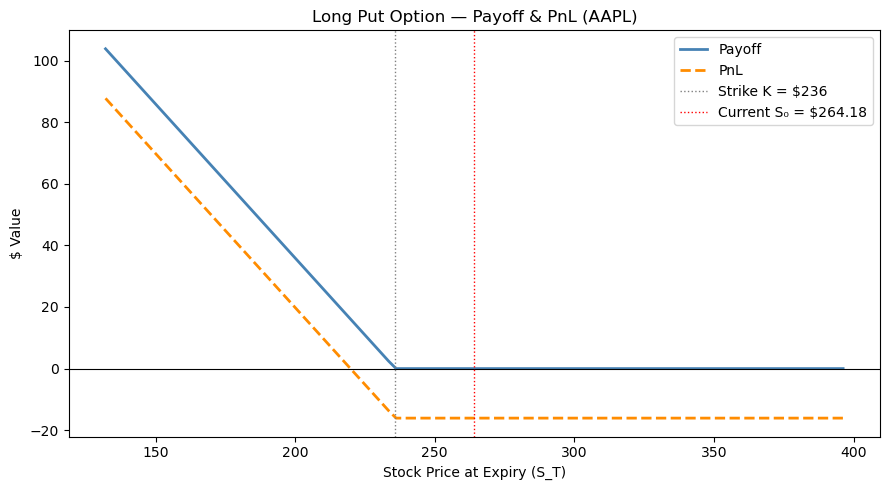

In [209]:
#Evaluate payoff and PnL at different stock prices at maturity
ST=np.linspace(0.5*S0, 1.5*S0, 100)
payoffs=np.maximum(K-ST,0)
pnl=payoffs - P

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ST, payoffs, label="Payoff", linewidth=2, color="steelblue")
ax.plot(ST, pnl,    label="PnL",    linewidth=2, color="darkorange", linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(K, color="gray", linewidth=1, linestyle=":", label=f"Strike K = ${K:.0f}")
ax.axvline(S0, color="red", linewidth=1, linestyle=":",
           label=f"Current S₀ = ${S0:.2f}")
ax.set_xlabel("Stock Price at Expiry (S_T)")
ax.set_ylabel("$ Value")
ax.set_title("Long Put Option — Payoff & PnL (AAPL)")
ax.legend()
plt.tight_layout()
plt.show()

The put is currently out-of-the-money since S0 > K. The buyer of the put profits only if AAPL falls below the breakeven(K-P). The Maximum loss is capped at the premium paid (P), while the maximum gain is K-P (if stock goes to zero). This asymmetric risk profile is the key advantage of buying put options for downside protection.

## Greeks

Greeks are vital tools in risk management, it represents the first-order sensitivities of option price to changes in one underlying parameter.

(Assuming for Vega, 2.5% increase in volatility, for Rho, 1.4% increase in the risk-free rate.)

| Greek | Formula | Definition |
| --- | --- | --- |
| Delta | $\Delta = N(d_1)$ | sensitivity to underlying price |
| Gamma | $\Gamma = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}}$ | sensitivity of Delta |
| Theta (daily) | $\Theta = \frac{-S_0 N'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2)$, then divide by 252 | time decay |
| Vega | $\mathcal{V} = S_0 \sqrt{T} N'(d_1)$, then multiply by 0.025 | sensitivity to volatility |
| Rho | $\rho = KTe^{-rT}N(d_2)$, then multiply by 0.014 | sensitivity to interest rates |

where $N'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ (standard normal PDF).



In [210]:
delta=N(d1(S0,K,r,sigma,T))
delta

0.7378669400417764

if AAPL increases by $1, the call price increases by approximately $0.74

**Deeper interpretation and for delta hedging:**
- Delta is between 0 and 1 for a call.
- Deep ITM call => Delta = 1
- Deep OTM call => Delta = 0
- ATM call => Delta = 0.5

Delta also represents number of shares needed to hedge one call.

In [211]:
gamma = norm.pdf(d1(S0,K,r,sigma,T)) / (S0*sigma*np.sqrt(T))
gamma

0.0038283519074339546

if AAPL increases by $1, Delta increases by 0.003.

**Deeper interpretation:**
- High Gamma => Delta unstable
- Gamma highest near ATM
- Gamma always positive for calls and puts.

Delta also represents the curvature of the option value and reflects how sensitive the delta is to changes in the underlying price.

In [212]:
theta = (-S0*norm.pdf(d1(S0,K,r,sigma,T))*sigma/(2*np.sqrt(T))
         - r*K*np.exp(-r*T)*norm.cdf(d2(S0,K,r,sigma,T))) / 252
theta

-0.07742039807466297

The option loses approximately $0.08 per day, all else equal.

**Deeper interpretation:**
- Calls usually have negative theta
- Time decay accelerates near maturity
- ATM options lose value fastest.

Theta captures the cost of time passing. For long options, time decay represents a systematic loss of calue as maturity approaches.

In [213]:
vega = S0 * norm.pdf(d1(S0,K,r,sigma,T)) * np.sqrt(T)
vega_impact = vega * 0.025
vega_impact

2.1512870700660356

if volatility increases by 2.5%, the call price increases by approximately $2.15.

**Deeper interpretation:**
- Vega highest for ATM options.
- Long calls benefit from volatility increases.


Vega reflects the sensitivity of the option price to changes in expected volatility. Long options are long volatility.

In [214]:
rho = K*T*np.exp(-r*T)*norm.cdf(d2(S0,K,r,sigma,T))
rho_impact = rho * 0.014
rho_impact

1.9784642886220485

if interest rates increase by 1.4%, the call price increases by approximately $1.98.

**Deeper interpretation:**
- Calls benefit from higher interest rates
- Puts lose value when rates rise

Why? Because higher rates reduce the present value of the strike

### **Insights:**
Greeks are local derivatives. They are only valid for small changes in their respective parameters. Afterall, it is linear approximations. In case of large moves, there are presence of non-linear effects, in this case, Gamma matters.

# Implied Volatility

Implied volatility reflects investors' perceptions of uncertainty or risk associated with the future movements of the underlying asset. Since volatility is the only parameter which is unobserved in Black-Scholes framework, it is important to grasp as it can be used to project future moves of option price. It can often be thought to be a proxy of market risk.

We often refer to the volatility smile, as it is related to the fact that options at different strikes have different levels of implied volatility. Graphing IV against strike prices for a given maturity produce a skewed "smile" instead of a flat surface.

IV is a good indicator to quantify market sentiment:
- IV generally increases in bearish markets, when investors believe prices will decline over time.
- IV decreases when in bullish market.

In quantitative finance, modeling the volatility smile is an active area of research, and better pricing models such as the stochastic volatility model partially address this issue.

A related concept is the term structure of volatility, which describes how IV differs for related options with different maturities. An IV surface is a 3-D plot that plots volatility smile and term structure of volatility in a consolidated three-dimensional surface for all options on a give underlying asset.

In [215]:
aapl=yf.Ticker("AAPL")

#available option expiries
expiries=aapl.options
print("Available Expiries:", expiries)

Available Expiries: ('2026-03-04', '2026-03-06', '2026-03-09', '2026-03-11', '2026-03-13', '2026-03-20', '2026-03-27', '2026-04-02', '2026-04-10', '2026-04-17', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


In [216]:
AS_OF_DATE = datetime.date(2026, 1, 1)
end_date=AS_OF_DATE.strftime("%Y-%m-%d")
start_date=(AS_OF_DATE - datetime.timedelta(days=30)).strftime("%Y-%m-%d")

target=AS_OF_DATE.replace(year=AS_OF_DATE.year + 1) #target 1Y expiry

expiries_dt = [datetime.datetime.strptime(e, "%Y-%m-%d").date() for e in expiries]

best_expiry = min(expiries_dt, key=lambda x: abs(x - target))
expiry_str = best_expiry.strftime("%Y-%m-%d")

T_market = (best_expiry - AS_OF_DATE).days / 365

print(f"Option expiry: {expiry_str} (T = {T_market:.4f} yrs)")

Option expiry: 2026-12-18 (T = 0.9616 yrs)


In [217]:
chain=aapl.option_chain(expiry_str)
calls=chain.calls
puts=chain.puts

#strike closest to K
call_row=calls.iloc[(calls["strike"]-K).abs().argsort()[:1]]
put_row=puts.iloc[(puts["strike"]-K).abs().argsort()[:1]]

K_call=float(call_row["strike"].values[0])
K_put=float(put_row["strike"].values[0])

call_market=float((call_row["bid"].values[0] + call_row["ask"].values[0]) / 2)
put_market=float((put_row["bid"].values[0] + put_row["ask"].values[0]) / 2)

print(f"\nCall: strike=${K_call:.2f},  mid-price=${call_market:.4f}")
print(f"Put:  strike=${K_put:.2f},  mid-price=${put_market:.4f}")


Call: strike=$235.00,  mid-price=$49.1250
Put:  strike=$235.00,  mid-price=$12.8250


## First method: Brute Force

In [219]:
def implied_vol_brute(market_price, S, K, r, T, option_type="call", step=0.0001, max_sigma=5):
    """Brute-force search for implied volatility."""
    #track the best sigma (minimum difference)
    best_sigma = None
    best_diff = float('inf')
    sigma=step

    while sigma < max_sigma:
        if option_type == "call":
            price = black_scholes_call(S, K, r, sigma, T)
        else:
            price = black_scholes_put(S, K, r, sigma, T)

        diff=abs(price - market_price)
        if diff < best_diff:
            best_diff = diff
            best_sigma = sigma

        #BS call price is monotonically increasing in sigma, so we can stop once we start getting higher prices than market
        if price > market_price:
            break
    
        sigma += step
    return best_sigma  # If no solution found within range

iv_call_brute=implied_vol_brute(call_market, S0, K_call, r, T_market, option_type="call")
iv_put_brute=implied_vol_brute(put_market, S0, K_put, r, T_market, option_type="put")

print(f"Brute force IV call: {iv_call_brute:.4f}")
print(f"Brute force IV put: {iv_put_brute:.4f}")

Brute force IV call: 0.2698
Brute force IV put: 0.2915


In [221]:
#replug to check if we get close to market price
call_price_replug=black_scholes_call(S0, K_call, r, iv_call_brute, T_market)
put_price_replug=black_scholes_put(S0, K_put, r, iv_put_brute, T_market)

print(f"\nReplug call price: ${call_price_replug:.4f} (market: ${call_market:.4f})")
print(f"Replug put price: ${put_price_replug:.4f} (market: ${put_market:.4f})")


Replug call price: $49.1218 (market: $49.1250)
Replug put price: $12.8257 (market: $12.8250)


key insight: BS option price is monotonically increasing in sigma, so there's exactly one sigma where price = market price. We just find the sigma that gets closest.

## Newton Raphson Algorithm
The Newton Raphson method is a widely used algorithm for calculating the implied volatility of an option. The steps for the generic algorithm are as follows:

1. Define our function as $f(x)$ for which we want to solve $f(x)=0$
2. Choose an initial guess
3. Iterate as follows: $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$
4. Break if: $|f(x_n)| <\epsilon$, here $\epsilon$ is the tolerance for error describes in the brute force method

Applying the staps above to our problem of solving implied volatility:
1. $f(\sigma) = V_{BS_\sigma} - V_{market}$
2. Initial guess $\sigma_0 = 0.05$ (chosen for convenience)
3. $\sigma_{n+1} = \sigma_n - \frac{V_{BS} - V_{\text{market}}}{\frac{\partial V_{BS_{\sigma}}}{\partial \sigma}}$
4. $|V_{BS} - V_{market}| <\epsilon$, return $\sigma_n$

In order to code this in Python we first need to make a function that computes the partial derivative of the value of a call option with respect to volatility. This partial derivative is commonly referred to as vega. 

$vega = S \sqrt{T}\Phi'(d1)$

Please note that $d1$ in $vega$ is the same $d_{1}=\frac{\ln \frac{S_{t}}{K} + (r + \frac{\sigma^2}{2})\tau}{\sigma\sqrt{\tau}}$ that we calculated in the Black-Scholes formula and $\Phi'$ is the probability density function for a standard normal distribution

In [222]:
def vega(S,K,r,sigma,T):
    return S * norm.pdf(d1(S,K,r,sigma,T)) * np.sqrt(T)

Now that we have a function to calculate vega, let's create a function to implement Newton's method on our case and compare it to the value we got with brute force

In [225]:
def implied_vol_newton(market_price, S, K, r, T, option_type="call", tol=1e-6, max_iter=1000):
    """Newton-Raphson method for implied volatility."""
    sigma = 0.2  # Initial guess
    for i in range(max_iter):
        if option_type == "call":
            price = black_scholes_call(S, K, r, sigma, T)
        else:
            price = black_scholes_put(S, K, r, sigma, T)

        diff=price - market_price

        if abs(diff) < tol:
            print(f"found on {i}th iteration")
            print(f"difference is equal to {diff}")
            return sigma
        
        if abs(vega(S,K,r,sigma,T)) < 1e-8:  # Avoid division by zero
            print("Vega is too small, stopping iteration.")
            break

        sigma-=diff/vega(S,K,r,sigma,T)
        
    return sigma

In [226]:
iv_call_nr=implied_vol_newton(call_market, S0, K_call, r, T_market, option_type="call")
iv_put_nr=implied_vol_newton(put_market, S0, K_put, r, T_market, option_type="put")

print(f"\nNewton-Raphson IV call: {iv_call_nr:.4f}")
print(f"Newton-Raphson IV put: {iv_put_nr:.4f}")

found on 3th iteration
difference is equal to 1.8837766901924624e-08
found on 3th iteration
difference is equal to 5.664776736580279e-08

Newton-Raphson IV call: 0.2698
Newton-Raphson IV put: 0.2915


In [228]:
#recheck replug with Newton-Raphson IV
call_price_replug_nr=black_scholes_call(S0, K_call, r, iv_call_nr, T_market)
put_price_replug_nr=black_scholes_put(S0, K_put, r, iv_put_nr, T_market)

print(f"\nReplug call price (NR IV): ${call_price_replug_nr:.4f} (market: ${call_market:.4f})")
print(f"Replug put price (NR IV): ${put_price_replug_nr:.4f} (market: ${put_market:.4f})")


Replug call price (NR IV): $49.1250 (market: $49.1250)
Replug put price (NR IV): $12.8250 (market: $12.8250)


Compare between two methods, we find it effectively identical. Whilst the brute force method works pretty well, it takes quite a while for brute force to finish, imagine having 1000 options to calculate implied volatility. It tooks roughly 6 seconds for the above script to finish, multiplying that by 1000 equates to well over an hourt of waiting.

Regarding Newton-Raphson method, one problem is when the vega will be close to zero which is the case if the option is considered as out of the money options.

# GBM and Monte Carlo implementation

What is a "Brownian Motion"?

It is a stochastic (=random) process used to describe the random movement of an object in a medium (gas, liquid).

What is a "Geometric Brownian motion" ?

Geometric Brownian motion (GBM) also known as an exponential Brownain motion, is a continuous time stochastic process in which the logarithm of the randomly varying quantity follows a brownian motion with drift. It is an important example of stochastic processes satisfying a stochastic differential equation (SDE); in particular, it is used in mathematical finance to model stock prices (in Black-Scholes framework).

SDE:
$$dS_t = \mu S_t , dt + \sigma S_t , dW_t$$

where $W_t$ is a Wiener process. This equation is nos in the form of an Ito process.

Ito's Lemma in short, states if a random variable follows an Ito Process (example above) then another twice differentiable function $G$ described by the stock price $S$ and time $t$ also follows at Ito process:

$dG(t, x) = \left( \frac{\partial G}{\partial S} S \mu + \frac{\partial G}{\partial t} + \frac{1}{2} \frac{\partial^2 G}{\partial S^2} S^2 \sigma^2 \right) dt + \frac{\partial G}{\partial S} S \sigma dW_t$

We could apply the Ito's lemma to $G = S$ in order to obtain arithmetic Brownian motion, howver using $G = ln(S)$ which gives a nice property that the stock price is strictly greater than 0. So applying Ito's lemma to $ln(S)$, we can based on Euler-Maruyama work.

Discretized (Euler-Maruyama):
$$S_{t+\Delta t} = S_t \cdot \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z\right], \quad Z \sim N(0,1)$$

In [230]:
def mc_call_gbm(S0, K, r, sigma, T, n_sims=20000, n_steps=252):
    # Ensure all inputs are plain floats
    S0, K, r, sigma, T = float(S0), float(K), float(r), float(sigma), float(T)
    
    dt = T / n_steps
    payoffs = []
    for _ in range(n_sims):
        S = S0
        for _ in range(n_steps):
            Z = np.random.standard_normal()
            S *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        payoffs.append(max(S - K, 0))
    return np.exp(-r * T) * np.mean(payoffs)

np.random.seed(42)  # For reproducibility
mc_price=mc_call_gbm(S0, K, r, sigma, T)
print(f"\nMonte Carlo call price: ${mc_price:.4f} (BS price: ${call_price:.4f})")


Monte Carlo call price: $52.8825 (BS price: $53.6108)


## Local Volatility
In the Black-Scholes model, volatility σ is assumed constant. In reality, 
implied volatility varies across strikes and maturities — the "volatility smile".

**Local Volatility** σ(S,t) is a deterministic function of the current stock 
price and time that is consistent with all observed market option prices simultaneously.

Mathematically, in a local volatility model, the GBM process is described as
$$dS_t = r S_t , dt + \sigma (S_t, t)S_t , dW_t$$

The local volatility surface was derived by Dupire (1994) via the following formula:

$$\sigma^2_{loc}(K,T) = \frac{\frac{\partial C}{\partial T}}{\frac{1}{2}K^2 \frac{\partial^2 C}{\partial K^2}}$$


where C(K,T) is the market call price as a function of strike K and maturity T.

The partial derivatives are approximated using finite differences:

$$\frac{\partial C}{\partial T} \approx \frac{C(K, T+\Delta T) - C(K, T-\Delta T)}{2\Delta T}$$

$$\frac{\partial^2 C}{\partial K^2} \approx \frac{C(K+\Delta K, T) - 2C(K,T) + C(K-\Delta K, T)}{\Delta K^2}$$

where $\Delta T = \frac{1}{252}$ (1 trading day) and $\Delta K = 1$ (one dollar).

We assume $\mu = r - q$ (risk-neutral drift, q=0 for no dividends).


In [233]:
def local_vol(S,K,r,sigma,T, dK=1,dT=1/252):
    """Dupire local volatility formula"""
    
    #Guard against degenerate inputs (S below 0)
    if S<=0 or T<=dT:
        return sigma
    C=black_scholes_call(S, K, r, sigma, T)
    C_T_up=black_scholes_call(S, K, r, sigma, T+dT)
    C_T_down=black_scholes_call(S, K, r, sigma, T-dT)
    C_K_up=black_scholes_call(S, K+dK, r, sigma, T)
    C_K_down=black_scholes_call(S, K-dK, r, sigma, T)

    dCdT=(C_T_up - C_T_down) / (2*dT)
    d2CdK2=(C_K_up - 2*C + C_K_down) / (dK**2)
    
    denominator=0.5*K**2 * d2CdK2
    if denominator <= 0:
        return sigma  # fallback to BS vol if we get non-positive denominator
    
    lv2=dCdT/denominator
    if lv2 < 0:
        return sigma  # fallback to BS vol if we get negative local variance
    
    return np.sqrt(lv2)

def mc_call_local_vol(S0, K, r, sigma, T, n_sims=20000, n_steps=252):
    dt = T / n_steps
    payoffs = []
    for _ in range(n_sims):
        S = S0
        for step in range(n_steps):
            t_rem = T - step * dt
            lv = local_vol(S, K, r, sigma, t_rem)
            Z = np.random.standard_normal()
            S *= np.exp((r - 0.5 * lv**2) * dt + lv * np.sqrt(dt) * Z)
        payoffs.append(max(S - K, 0))
    return np.exp(-r * T) * np.mean(payoffs)

uncomment the codes below to run it (if your computing power is strong enough)

In [ ]:
# np.random.seed(42)
# lv_price=mc_call_local_vol(S0, K, r, sigma, T)
# print(f"\nMonte Carlo with Local Vol call price: ${lv_price:.4f} (BS price: ${call_price:.4f})")

# Hedging
Hedging is a risk management strategy that involves taking an offsetting position in a related asset to reduce or eliminate exposure to an existing risk. It does not aim to generate profit, but to protect against adverse price movements.

Why use hedging strategies?
- Protect portfolio value against unfavorable market moves
- Reduce earnings volatility for corporations (FX, commodity exposure)
- Meet regulatory or risk mandate requirements
- Allow market makers to remain delta neutral while earning the bid-ask spread

Who uses?
- Corporations: hedge FX, commodity input costs (e.g. airlines hedging jet fuel)
- Fund managers: protect portfolio against drawdowns using put options or futures
- Market makers: hedge the options they sell by trading the underlying
- Individual investors: buy protective puts to insure long stock positions.

**Main approaches:**
| Approach | Description |
|---|---|
| Delta hedging | Neutralise sensitivity to small price moves |
| Gamma hedging | Neutralise sensitivity to large price moves |
| Vega hedging | Neutralise sensitivity to volatility changes |
| Theta hedging | Manage time decay of a portfolio |
| Static hedging | Set a hedge once (e.g. buy a put), do not rebalance |
| Dynamic hedging | Continuously rebalance (e.g. delta hedging) |


Precisely, a static hedging is a hedge that requires no adjustments to its components once it is initiated, in other words, the hedge won't need to be re-balanced irrespective of how the market moves.

Dynamic hedging, in contrary, actively adjusts according to market movements to ensure its hedge position. The frequency of which the hedge must be rebalanced depends on the nature of its sensitivities and its impact on the price.

## Delta hedging
Delta hedging neutralises the portfolio's sensitivity to small price moves. A delta-neutral portfolio satisfies: Σ(position × delta) = 0

**Covered call**:short call options against a long stock position
**Portfolio delta**= $$\Delta_{shares} + N_{options} \cdot \Delta_{call} = 0$$
$$ → N_{options}=\frac{-shares}{\Delta_{call}} \quad (negative=short)$$

In [238]:
shares =25000 #assume we are long 25000 shares on AAPL
delta_call=N(d1(S0,K,r,sigma,T))
delta_put=delta_call - 1 #call-put parity

n_calls=-shares/delta_call

print("delta of call:", delta_call)
print("delta of put:", delta_put)
print(f"Number of calls to delta-hedge: {abs(n_calls):.2f}")

delta of call: 0.7378669400417764
delta of put: -0.26213305995822356
Number of calls to delta-hedge: 33881.45


In [239]:
#verification
shares +n_calls*delta_call

0.0

Effect of $1.5 price increase (first-order / delta approximation)

In [240]:
dprice=1.5
gain_shares=shares*dprice
ajustment_calls=n_calls*delta_call*dprice

net_pnl=gain_shares + ajustment_calls

print("Gain from shares:", gain_shares)
print("Adjustment from calls:", ajustment_calls)
print(f"Net PnL from delta-hedged position: ${net_pnl:.2f}")

Gain from shares: 37500.0
Adjustment from calls: -37500.0
Net PnL from delta-hedged position: $0.00


In [243]:
#rebalance after price change
S_new=S0 + dprice
delta_call_new=N(d1(S_new,K,r,sigma,T))

ptf_delta_new=shares+n_calls*delta_call_new

n_calls_new=-shares/delta_call_new
adjustment_calls_new=n_calls_new - n_calls

print(f"Original delta: {delta_call:.4f}, New delta: {delta_call_new:.4f}")
print(f"portfolio delta after price change (before rebalancing): {ptf_delta_new:.4f}")
print(f"original short position in calls: {n_calls:.2f}, new position in calls after rebalancing: {n_calls_new:.2f}, adjustment needed: {adjustment_calls_new:.2f}")
print(f"Verification — new portfolio delta: {shares + n_calls_new * delta_call_new:.6f}")

Original delta: 0.7379, New delta: 0.7436
portfolio delta after price change (before rebalancing): -192.9231
original short position in calls: -33881.45, new position in calls after rebalancing: -33621.99, adjustment needed: 259.46
Verification — new portfolio delta: 0.000000


The portfolio is flat: delta hedge absorbed the price move. When it comes to an increase in stock price, we'll exit a fraction of short positions in calls in order to maintain delta-neutral. We can also observed that, the delta has increased as a result.

## Gamma hedging
Gamma measures how much delta changes when the stock moves. A delta-only hedge breaks down after large moves because delta itself shifts. Adding a gamma neutral position protects against this curvature risk.

**Steps:**
1. Compute portfolio gamma
2. Add a hedge option: $$N_h = −\frac {Γ_{portfolio}}{Γ_{hedge}}$$
3. Portfolio delta is now disturbed → restore delta-neutral using shares
   (shares have Δ=1, Γ=0 → adjusting shares fixes delta without affecting gamma)

Source for hedge option: Black-Scholes call with $K_h = K×1.05,\quad T_h = 0.5 years.$

In [257]:
gamma_call=norm.pdf(d1(S0,K,r,sigma,T)) / (S0*sigma*np.sqrt(T))
portfolio_gamma=n_calls*gamma_call

print(f"Gamma of call: {gamma_call:.6f}")
print(f"Portfolio gamma: {portfolio_gamma:.6f}\n")

#Hedge option - different strike and maturity
K_h=K*1.05 #5% OTM call
T_h = 0.5 #6 months to expiry

delta_h=N(d1(S0,K_h,r,sigma,T_h))
gamma_h=norm.pdf(d1(S0,K_h,r,sigma,T_h)) / (S0*sigma*np.sqrt(T_h))

print(f"Hedging option delta: {delta_h:.4f}, gamma: {gamma_h:.6f}, [source: BS model]")

#Number of hedge option to neutralize gamma
N_h=-portfolio_gamma / gamma_h
print(f"{'BUY' if N_h>0 else 'SELL'} {abs(N_h):.2f} hedge options to neutralize gamma\n")
#verification
portfolio_gamma_new=portfolio_gamma+N_h*gamma_h
print("verification:", portfolio_gamma_new)

Gamma of call: 0.003828
Portfolio gamma: -129.710104

Hedging option delta: 0.6860, gamma: 0.005896, [source: BS model]
BUY 21998.52 hedge options to neutralize gamma

verification: 0.0


In [251]:
#restore delta neutral after gamma hedge
#delta portfolio after gamma hedge
delta_portfolio_after_gamma_hedge=N_h*delta_h + 0 #0 = delta-neutral

print(f"Portfolio delta after gamma hedge: {delta_portfolio_after_gamma_hedge:.6f}")

Portfolio delta after gamma hedge: 15091.565000


In [254]:
#fix delta using shares with delta one and gamma 0
shares_adjustments=-delta_portfolio_after_gamma_hedge
print(f"{'BUY' if shares_adjustments>0 else 'SELL'} {abs(shares_adjustments):.2f} shares to restore delta neutrality")

#verification after full hedge
final_delta=delta_portfolio_after_gamma_hedge + shares_adjustments
final_gamma=portfolio_gamma_new

print("Delta",final_delta)
print("Gamma",final_gamma)

SELL 15091.56 shares to restore delta neutrality
Delta 0.0
Gamma 0.0


It is not possible to have a delta gamma neutral position. Anytime gamma is recalibrated, the quantity of delta in the portfolio will change because of gamma adjustments.

HOWEVER, it becomes possible by adjusting with shares to neutralize delta, that doesn't affect gamma.

By adding N_h hedge options we neutralise gamma. The resulting delta imbalance is then corrected by adjusting the share position, which carries no gamma. This two-instrument approach achieves a simultaneously delta-gamma neutral portfolio

## Vega Hedging
Vega measures sensitivity of the option price to changes in volatility. A vega-neutral portfolio is protected against volatility shifts.

**steps:**
1. Determine the total vega of current porfolio
2. Identify options with vega values that are opposite in sign to current porfolio vega.
3. Calculate the quantity of offset positions  needed to neutralize the portfolio vega.

**Call Spread position:**
- Long call at strike K
- Short call at strike K*1.3 (assume strike 30% higher)

Portfolio vega= $V_{long} - V_{short}

To neutralise: add a third option such that:
$N_h=\frac -V_{portfolio}{V_{hedge}}

NOTE: vega is always positive for long options and negative for short options.
An OTM short call has lower vega than an ATM call => the pread has net positive vega.

In [261]:
K_short=K*1.3
price_long_call=black_scholes_call(S0, K, r, sigma, T)
price_short_call=black_scholes_call(S0, K_short, r, sigma, T)

vega_long=vega(S0, K, r, sigma, T)
vega_short=vega(S0, K_short, r, sigma, T)
portfolio_vega=vega_long-vega_short

print(f"long call K={K:.2f}, price=${price_long_call:.4f}, vega={vega_long:.4f}")
print(f"short call K={K_short:.2f}, price=${price_short_call:.4f}, vega={vega_short:.4f}")
print(f"portfolio vega: {portfolio_vega:.4f}\n")

#hedge option (different strike and maturity)
K_h=K*1.15
T_h=0.75 #9 months to expiry
price_h=black_scholes_call(S0, K_h, r, sigma, T_h)
vega_h=vega(S0, K_h, r, sigma, T_h)

print(f"K_h={K_h:.2f}, T_h={T_h:.2f} yrs, price={price_h:.4f}, vega={vega_h:.4f}")

N_h=-portfolio_vega / vega_h
print(f"{'BUY' if N_h>0 else 'SELL'} {abs(N_h):.2f} hedge options to neutralize vega\n")

#verification
final_vega=portfolio_vega + N_h*vega_h
print(f"verification: {final_vega:.4f}")

long call K=235.90, price=$53.6108, vega=86.0515
short call K=306.67, price=$22.5266, vega=103.7390
portfolio vega: -17.6875

K_h=271.28, T_h=0.75 yrs, price=29.7090, vega=90.2261
BUY 0.20 hedge options to neutralize vega

verification: 0.0000


heres we now vega is highest ATM, so long call is ITM and short call is closer to ATM. Giving so, we have negative portfolio vega, meaning the porfolio loses value when volatility increases.

To achieve vega-neutrality, we buy 0.2 units of the hedge option (long position).

## Theta hedging

### What is Theta?
Theta (Θ) measures the daily loss of an option's value due to time passing,
all else equal. It is almost always negative for long options — time decay erodes value.

### Butterfly Spread
We hold an existing butterfly spread on AAPL:
- **Long 1 call**  at K₁ = K × 0.90  (ITM)
- **Short 2 calls** at K₂ = K         (ATM — middle strike)
- **Long 1 call**  at K₃ = K × 1.10  (OTM)

The butterfly profits when the stock stays near K₂ at expiry.
Since the two short ATM calls carry the largest theta in magnitude,
the butterfly typically has **positive portfolio theta** — it *gains* from time passing.

### Theta Neutralisation
To neutralise theta we add a hedge option on top of the existing butterfly:

$$N_h = -\frac{\Theta_{portfolio}}{\Theta_{hedge}}$$

A positive portfolio theta requires buying an option (negative theta) to offset it.


In [263]:
def theta_call(S,K,r, sigma,T):
    t1=-S*norm.pdf(d1(S,K,r,sigma,T))*sigma/(2*np.sqrt(T))
    t2=-r*K*np.exp(-r*T)*N(d2(S,K,r,sigma,T))
    return (t1+t2) / 252 #daily

K1=K*0.9    #ITM call
K2=K        #ATM call
K3=K*1.1    #OTM call

price_K1=black_scholes_call(S0, K1, r, sigma, T)
price_K2=black_scholes_call(S0, K2, r, sigma, T)
price_K3=black_scholes_call(S0, K3, r, sigma, T)

theta_K1=theta_call(S0, K1, r, sigma, T)
theta_K2=theta_call(S0, K2, r, sigma, T)
theta_K3=theta_call(S0, K3, r, sigma, T)

butterfly_price=price_K1 - 2*price_K2 + price_K3
butterfly_theta=theta_K1 - 2*theta_K2 + theta_K3

print("Existing Butterfly Position")
print("=" * 55)
print(f"{'Leg':<20} {'Strike':>8} {'Price':>10} {'Theta/day':>12}")
print("-" * 55)
print(f"{'Long  1 call':<20} ${K1:>7.2f} ${price_K1:>9.4f} {theta_K1:>12.6f}")
print(f"{'Short 2 calls':<20} ${K2:>7.2f} ${price_K2:>9.4f} {theta_K2:>12.6f}  (×2)")
print(f"{'Long  1 call':<20} ${K3:>7.2f} ${price_K3:>9.4f} {theta_K3:>12.6f}")
print("-" * 55)
print(f"{'Butterfly price':<20}          ${butterfly_price:>9.4f}")
print(f"{'Portfolio theta':<20}          {butterfly_theta:>12.6f} /day")


Existing Butterfly Position
Leg                    Strike      Price    Theta/day
-------------------------------------------------------
Long  1 call         $ 212.31 $  69.0683    -0.066266
Short 2 calls        $ 235.90 $  53.6108    -0.077420  (×2)
Long  1 call         $ 259.49 $  40.8038    -0.083631
-------------------------------------------------------
Butterfly price               $   2.6506
Portfolio theta                   0.004944 /day


In [265]:
#hedge option
K_h=K*1.05
T_h=0.5
price_h=black_scholes_call(S0, K_h, r, sigma, T_h)
theta_h=theta_call(S0, K_h, r, sigma, T_h)

print(f"Hedging option K={K_h:.2f}, T={T_h:.2f} yrs, price={price_h:.4f}, theta={theta_h:.6f} /day")

#theta neutral
N_h=-butterfly_theta / theta_h
print(f"{'BUY' if N_h>0 else 'SELL'} {abs(N_h):.2f} hedge options to neutralize theta\n")

#verification
final_theta=butterfly_theta + N_h*theta_h
print(f"verification: {final_theta:.6f}")

Hedging option K=247.69, T=0.50 yrs, price=35.2289, theta=-0.107868 /day
BUY 0.05 hedge options to neutralize theta

verification: 0.000000


The butterfly has positive theta, confirming that the short ATM calls dominate the position's time decay, the portfolio earns value daily from theta alone.

To neutralise this, we buy 0.05 options (negative theta), adding daily time decay cost back to the portfolio.

**Key trade-off**: buying the hedge option re-introduces negative theta cost
but also adds gamma and vega exposure. Achieving full simultaneous neutrality
across all Greeks requires multiple instruments and continuous rebalancing —
a reminder that Greek hedging is always a set of practical approximations.


# Binomial model
The binomial model discretises time into N steps of length $\Delta t=\frac {T}{N}$

At each step the stock moves up by factor u or down by factor d.

**Cox-Ross-Rubinstein (CRR) parameters:**

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u}, \quad p = \frac{e^{r\Delta t} - d}{u - d}$$

where p is the risk-neutral probability of an up-move.

**Backward induction — American feature:**

At every node, the holder can exercise early. The option value is:

$$V = \max\underbrace{(S - K)}_{\text{exercise now}},\ \underbrace{e^{-r\Delta t}[p \cdot V_u + (1-p) \cdot V_d]}_{\text{hold}}$$

This distinguishes it from a European option, where early exercise is ignored.

**Theoretical result:** For a non-dividend paying stock, it is never optimal
to early-exercise an American call, because the time value is always positive.
Therefore the American call price ≈ European call price.

In [266]:
def binomial_american_call(S0,K,r,sigma,T,N=100):
    dt=T/N
    u=np.exp(sigma*np.sqrt(dt))
    d=1/u
    p=(np.exp(r*dt)-d)/(u-d)
    disc=np.exp(-r*dt)

    print(f"Binomial parameters:")
    print(f"  N={N} steps,  dt={dt:.6f}")
    print(f"  u={u:.6f},  d={d:.6f},  p={p:.6f}")

    # Step 1 — terminal stock prices at maturity
    j      = np.arange(N + 1)
    S_T    = S0 * u**j * d**(N - j)

    # Step 2 — terminal payoffs
    values = np.maximum(S_T - K, 0)

    # Step 3 — backward induction through the tree
    for i in range(N - 1, -1, -1):
        S_now  = S0 * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
        hold   = disc * (p * values[1:] + (1 - p) * values[:-1])
        exercise = np.maximum(S_now - K, 0)   # early exercise
        values = np.maximum(hold, exercise)    # American: take the best

    return values[0]

american_price=binomial_american_call(S0, K, r, sigma, T, N=100)
european_price=call_price #from BS closed form

print(f"\nAmerican call price (Binomial tree): ${american_price:.4f}")
print(f"European call price (Black-Scholes): ${european_price:.4f}")
print(f"Early exercise premium: ${american_price - european_price:.4f}")



Binomial parameters:
  N=100 steps,  dt=0.010000
  u=1.032731,  d=0.968306,  p=0.498159

American call price (Binomial tree): $53.6424
European call price (Black-Scholes): $53.6108
Early exercise premium: $0.0316


The binomail American call price closely matches the Black-Scholes European call price, with an early exercise premium of $0.03. This confirms the theoretical result: for a non-divident paying asset, early exercise of a call is never optimal because:

1. Exercising early forfeits the remaining **time value**
2. It is always better to sell the option than to exercise it
3. Holding the option preserves downside protection

The binomial model converges to the Black-Scholes price as N goes to infinity, validating both approaches.